In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

In [10]:
#参数
dela = 1
t = 38 * dela
af = 400/0.1875* dela * 10**(-10)
a = 10**(-10)#/(400/6)
mu = 8 * dela
U = 1.9 * dela
mz = 7 * dela
h = 1.2 * np.sqrt(mu**2 + dela**2)
#L = 11
chaodaojiao = np.pi / 2
saimanjiao = np.pi / 4
#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.eye(2, dtype=complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy
Delta_L=dela * np.exp(1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_center_block=(U-mu+2*t)*s0+mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    
H_center_right_to_left_hop=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy
Delta_R=dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])


In [4]:
import numpy as np

def build_block_hamiltonian(
    Lpot, centerpot, Rpot,
    H_L_onsite, H_center, H_R,
    H_L_right_to_left_hop,
    H_center_right_to_left_hop,
    H_R_right_to_left_hop,
    H_center_to_L,
    H_R_to_center
):
    """
    构造由 4×4 block 组成的三段式 Hamiltonian 矩阵
    """

    N = Lpot + centerpot + Rpot
    dim = 4 * N
    H = np.zeros((dim, dim), dtype=complex)

    def set_block(i, j, block):
        H[4*i:4*(i+1), 4*j:4*(j+1)] = block

    # ========= 对角块 =========
    for i in range(N):
        if i < Lpot:
            set_block(i, i, H_L_onsite)
        elif i < Lpot + centerpot:
            set_block(i, i, H_center)
        else:
            set_block(i, i, H_R)

    # ========= 区内 hopping =========
    for i in range(N - 1):

        # Left 区
        if i < Lpot - 1:
            set_block(i, i+1, H_L_right_to_left_hop)
            set_block(i+1, i, H_L_right_to_left_hop.conj().T)

        # Center 区
        elif Lpot <= i < Lpot + centerpot - 1:
            set_block(i, i+1, H_center_right_to_left_hop)
            set_block(i+1, i, H_center_right_to_left_hop.conj().T)

        # Right 区
        elif i >= Lpot + centerpot:
            set_block(i, i+1, H_R_right_to_left_hop)
            set_block(i+1, i, H_R_right_to_left_hop.conj().T)

    # ========= 区域连接 hopping =========

    # L <-> Center
    i = Lpot - 1
    set_block(i, i+1, H_center_to_L)
    set_block(i+1, i, H_center_to_L.conj().T)

    # Center <-> R
    i = Lpot + centerpot - 1
    set_block(i, i+1, H_R_to_center)
    set_block(i+1, i, H_R_to_center.conj().T)

    return H


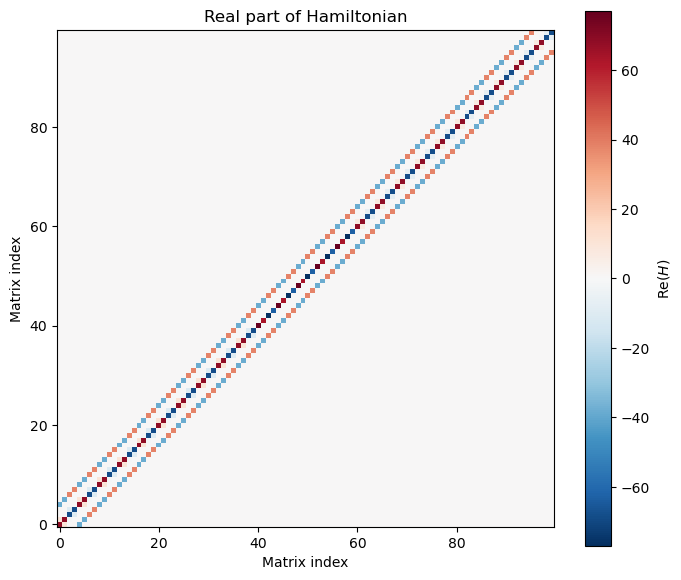

In [5]:
Lpot = 10
centerpot = 5
Rpot = 10

H = build_block_hamiltonian(
    Lpot, centerpot, Rpot,
    H_L_onsite, H_center, H_R_onsite,
    H_L_right_to_left_hop,
    H_center_right_to_left_hop,
    H_R_right_to_left_hop,
    H_center_to_L,
    H_R_to_center
)
plt.figure(figsize=(7, 6))

plt.imshow(
    H.real,
    origin="lower",
    cmap="RdBu_r",   # 正负清晰
    aspect="equal"
)

plt.colorbar(label=r"$\mathrm{Re}(H)$")

plt.xlabel("Matrix index")
plt.ylabel("Matrix index")
plt.title("Real part of Hamiltonian")

plt.tight_layout()
plt.show()


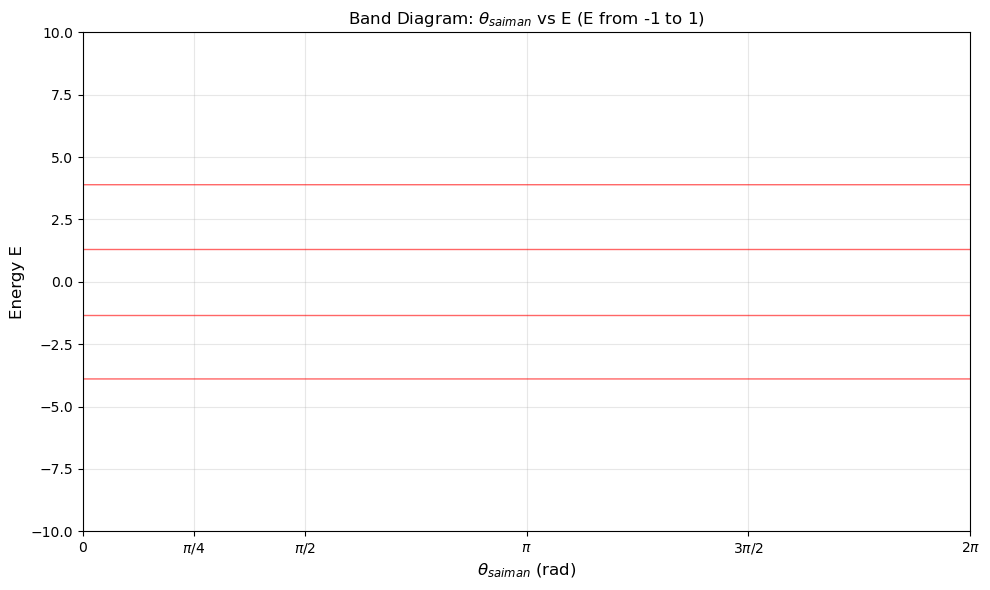

In [14]:
import numpy as np
import matplotlib.pyplot as plt


Lpot = Rpot = 15
centerpot=10
num_points = 100
saimanjiao_array = np.linspace(0, 2*np.pi, num_points)


eigenvalues_all = []

for idx, saimanjiao in enumerate(saimanjiao_array):
    # 更新右边矩阵信息（随saimanjiao变化）
    HR_block = -(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy
    Delta_R = dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_R_onsite = np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
    
    H_R_right_to_left_hop_block = -1*(t*s0+1j*af/a*sz)
    H_R_right_to_left_hop = np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])
    
    # 构建哈密顿量
    H_total = build_block_hamiltonian(
        Lpot, centerpot, Rpot,
        H_L_onsite, H_center, H_R_onsite,
        H_L_right_to_left_hop,
        H_center_right_to_left_hop,
        H_R_right_to_left_hop,
        H_center_to_L,
        H_R_to_center
    )
    
    # 计算特征值
    eigenvalues = np.linalg.eigvalsh(H_total)
    eigenvalues_all.append(eigenvalues)

eigenvalues_all = np.array(eigenvalues_all)

plt.figure(figsize=(10, 6))
for i in range(eigenvalues_all.shape[1]):
    plt.plot(saimanjiao_array, eigenvalues_all[:, i], 'r-', linewidth=1, alpha=0.6)

plt.xlabel(r'$\theta_{saiman}$ (rad)', fontsize=12)
plt.ylabel('Energy E', fontsize=12)
plt.title(r'Band Diagram: $\theta_{saiman}$ vs E (E from -1 to 1)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2*np.pi)
plt.ylim(-10, 10)


special_points = [0, np.pi/4, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
special_labels = ['0', r'$\pi/4$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
plt.xticks(special_points, special_labels)

# 添加零能线
#plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()